<a href="https://colab.research.google.com/github/ritabrezznica/DeepLearning/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing for Credit Card Default Prediction
This notebook covers all preprocessing steps, exploratory data analysis (EDA), and justifications for choices. The goal is to prepare the dataset for neural network training.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from joblib import dump

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

`RANDOM_STATE` ensures reproducibility.
- `matplotlib` and `seaborn` are used for EDA.

**Load Dataset**

In [53]:

df = pd.read_excel("/content/drive/MyDrive/default of credit card clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


First row contains metadata, and the second row has column names. ID is dropped because it does not contribute to prediction.

In [73]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 LIMIT_BAL                     0
SEX                           0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
MARRIAGE_1                    0
MARRIAGE_2                    0
MARRIAGE_3                    0
EDUCATION_1                   0
EDUCATION_2                   0
EDUCATION_3                   0
EDUCATION_4                   0
dtype: int64


Shows that all features are complete.

In [54]:
#Drop ID column as it is not informative for modeling
df = df.drop(columns=['ID'])
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**Exploratory Data Analysis (EDA)**


>**Target Variable Distribution**



default payment next month
0    23364
1     6636
Name: count, dtype: int64


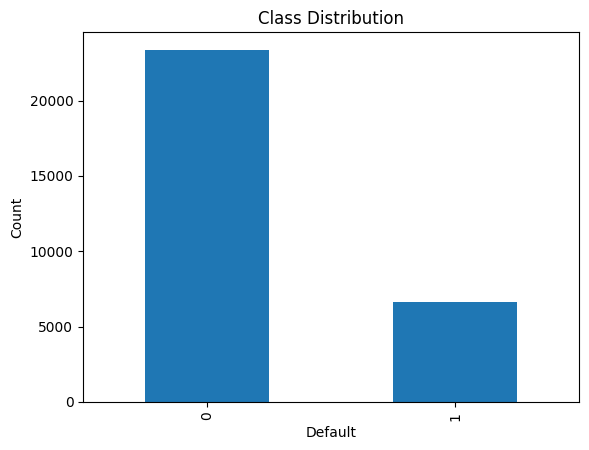

In [71]:
import matplotlib.pyplot as plt

# Target distribution
target_counts = df['default payment next month'].value_counts()
print(target_counts)

# Bar plot
target_counts.plot(kind='bar', title='Class Distribution')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

Target variable is binary: 0 = No Default, 1 = Default.
Class distribution is slightly imbalanced, which may affect model training.

**Summary Statistics**

In [41]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


.describe() shows min, max, mean, std, etc. for each feature.

**Feature Correlation with Target**

default payment next month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default payment nex

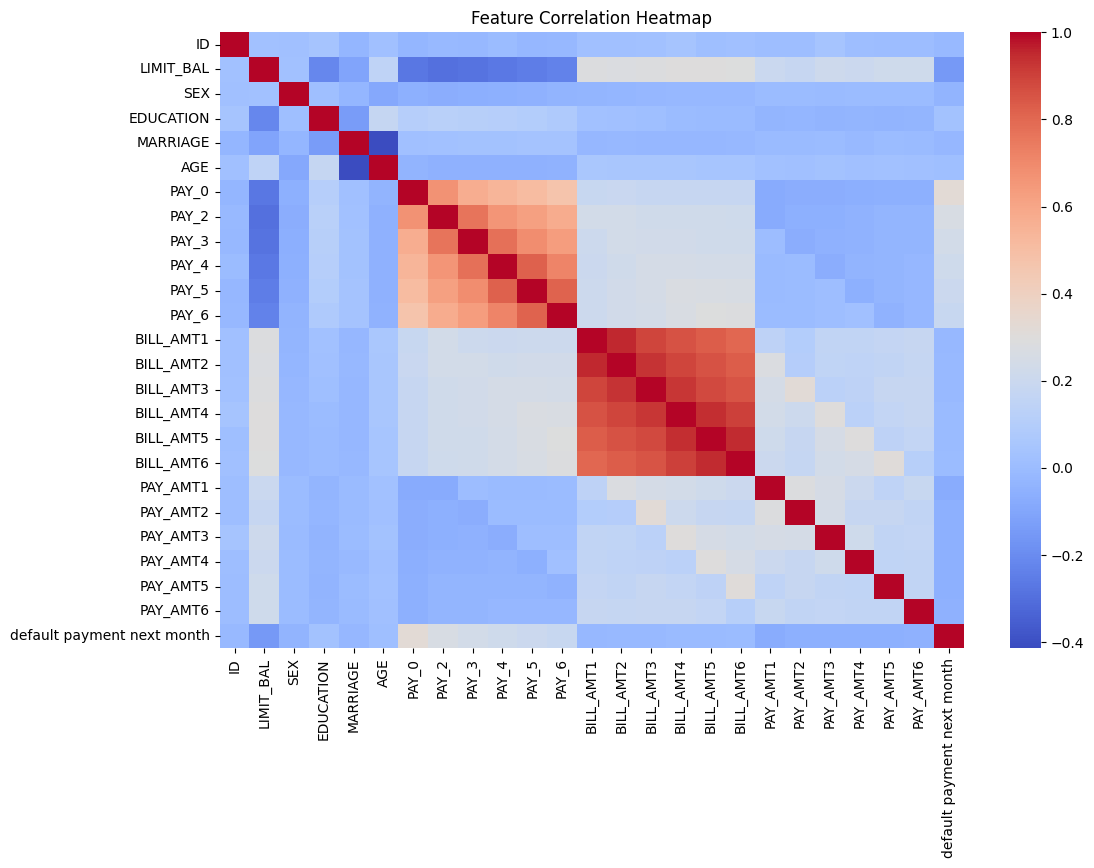

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of features with target
correlation = df.corr()['default payment next month'].sort_values(ascending=False)
print(correlation)

# Optional heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Feature Distribution Plots**

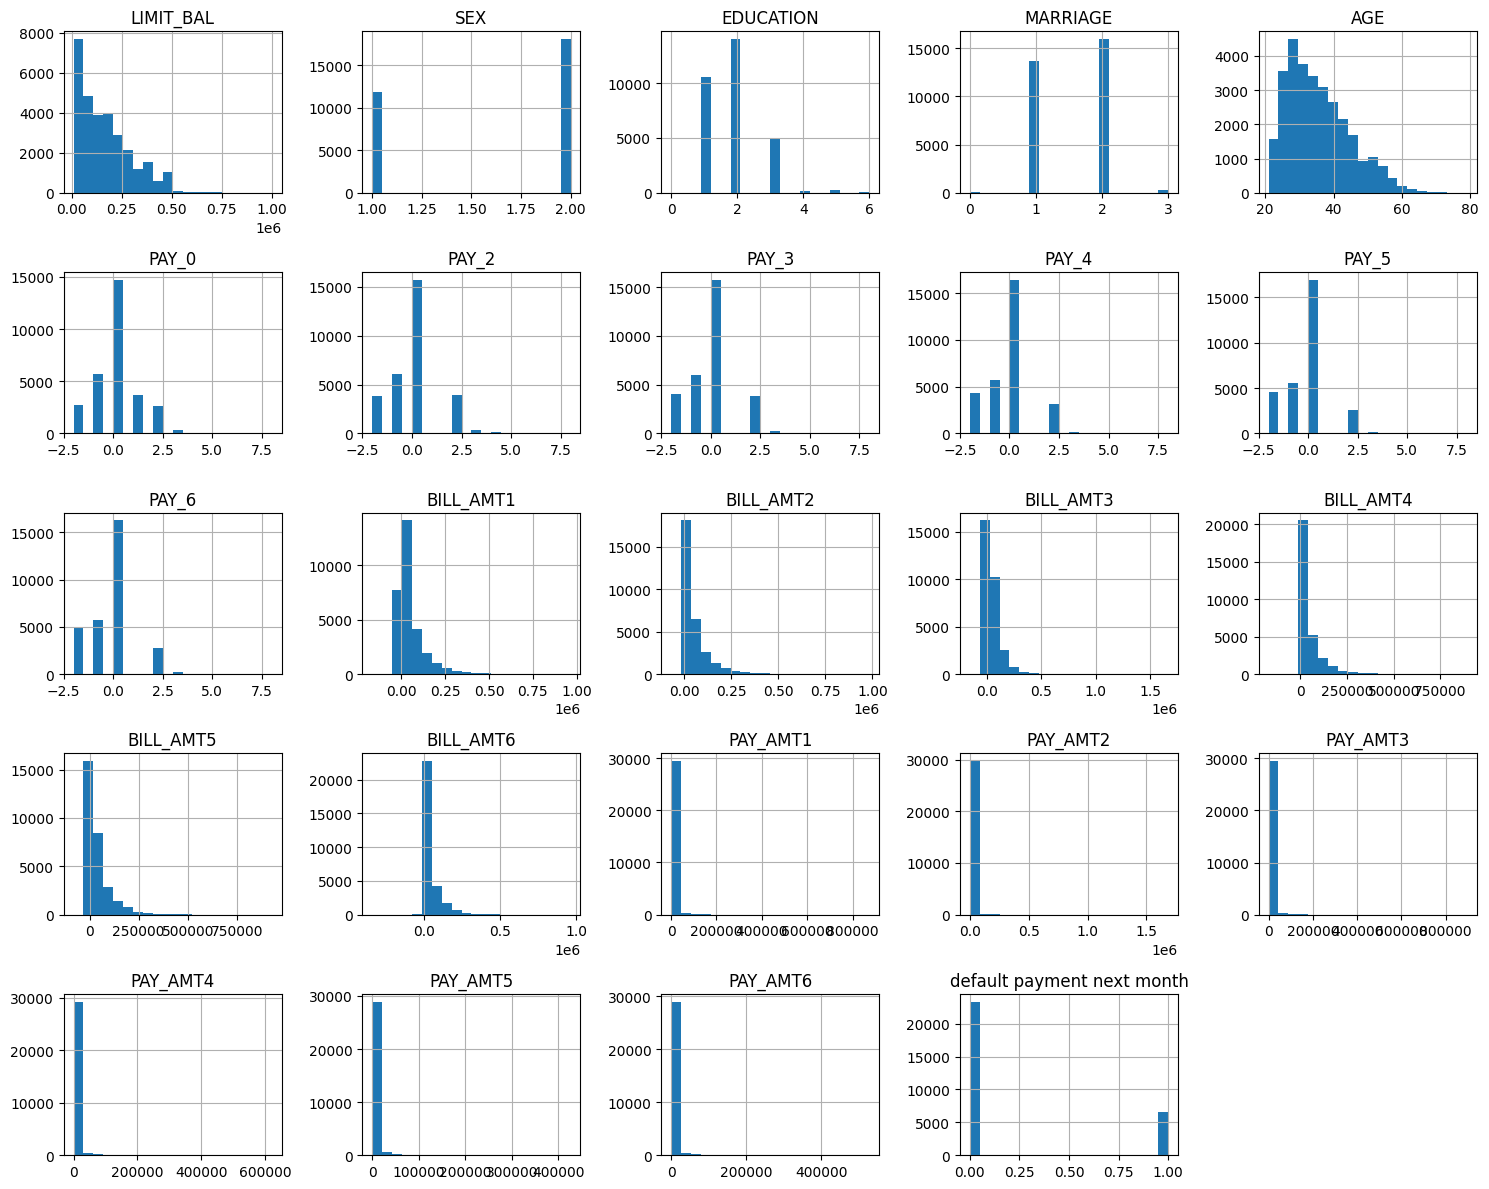

In [56]:
# Plot histograms for numerical features
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

Visualizing feature distributions helps identify skewness, outliers, or unusual ranges.
Neural networks perform better when features are normalized.

**Preprocessing Categorical and Numerical Features**

The dataset contains a mix of categorical (discrete) and numerical (continuous) variables:

1. Categorical Features
SEX: 1 = male, 2 = female
Binary feature → encoded as 0/1 for modeling.
MARRIAGE: 1 = married, 2 = single, 3 = others
Multi-class → replace invalid 0 with 3, then optionally one-hot encode.
EDUCATION: 1 = graduate school, 2 = university, 3 = high school, 4 = others
Replace invalid or rare values (0, 5, 6) with 4.

In [57]:
# Handle invalid or rare categories
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Encode SEX as binary
df['SEX'] = df['SEX'].map({1: 0, 2: 1})

# Optional: one-hot encode MARRIAGE and EDUCATION
df = pd.get_dummies(df, columns=['MARRIAGE', 'EDUCATION'], prefix=['MARRIAGE', 'EDUCATION'])

print(df[['SEX', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4',
          'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']].head())

   SEX  EDUCATION_1  EDUCATION_2  EDUCATION_3  EDUCATION_4  MARRIAGE_1  \
0    1        False         True        False        False        True   
1    1        False         True        False        False       False   
2    1        False         True        False        False       False   
3    1        False         True        False        False        True   
4    0        False         True        False        False        True   

   MARRIAGE_2  MARRIAGE_3  
0       False       False  
1        True       False  
2        True       False  
3       False       False  
4       False       False  


In [58]:
df.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT5,PAY_AMT6,default payment next month,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4
0,20000,1,24,2,2,-1,-1,-2,-2,3913,...,0,0,1,True,False,False,False,True,False,False
1,120000,1,26,-1,2,0,0,0,2,2682,...,0,2000,1,False,True,False,False,True,False,False
2,90000,1,34,0,0,0,0,0,0,29239,...,1000,5000,0,False,True,False,False,True,False,False
3,50000,1,37,0,0,0,0,0,0,46990,...,1069,1000,0,True,False,False,False,True,False,False
4,50000,0,57,-1,0,-1,0,0,0,8617,...,689,679,0,True,False,False,False,True,False,False


Numerical Features
Continuous variables: LIMIT_BAL, AGE, BILL_AMT1-6, PAY_AMT1-6
Can be used as-is or scaled/normalized for neural networks.
Payment status features: PAY_0 to PAY_6
Discrete but ordered, negative values like -1 indicate no delay → keep as-is.

**Split dataset**

In [50]:
# Separate features and target
X = df.drop(columns=['default payment next month'])
y = df['default payment next month']

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

`stratify=y` ensures the class distribution is maintained in train/test sets.Random state ensures reproducibility.

**Feature Scaling**

In [60]:
# Split dataset into train and test sets, maintaining class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print shapes
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (24000, 29), X_test shape: (6000, 29)
y_train shape: (24000,), y_test shape: (6000,)


# Categorical Columns
`SEX`, `EDUCATION`, and `MARRIAGE` are categorical variables.  
- SEX is binary (Male/Female)  
- EDUCATION and MARRIAGE are multi-class  
We define them to preprocess and encode correctly for the model.

In [64]:
cat_cols = [col for col in X.columns if col == 'SEX' or col.startswith('EDUCATION_') or col.startswith('MARRIAGE_')]

In [65]:
# Extract already one-hot encoded categorical columns from X_train and X_test
X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]

print(f"X_train_cat shape: {X_train_cat.shape}")
print(f"X_test_cat shape: {X_test_cat.shape}")

X_train_cat shape: (24000, 8)
X_test_cat shape: (6000, 8)


In [66]:
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join='left', axis=1, fill_value=0)

The categorical features for training and testing have been aligned. Next, these features will be converted to a bipolar representation (-1 and 1).

In [67]:
#Convert 0 → -1 for bipolar features (-1, 1) for neural network input
X_train_bipolar = X_train_cat.astype(float).replace({0: -1.0})
X_test_bipolar = X_test_cat.astype(float).replace({0: -1.0})

In [31]:
print(f"Bipolar Shape: {X_train_bipolar.shape}")
print(f"Sample Bipolar Row:\n{X_train_bipolar.iloc[0].values[:5]}...")

Bipolar Shape: (24000, 9)
Sample Bipolar Row:
[-1.  1. -1.  1. -1.]...


In [32]:
num_cols = [col for col in X.columns if col not in cat_cols]
print(f"Scaling {len(num_cols)} numerical columns...")


Scaling 20 numerical columns...


 Select numerical columns
- `num_cols` includes all columns **not in categorical columns** (`SEX`, `EDUCATION`, `MARRIAGE`)  
- These are the features that will be **scaled** to improve neural network training

In [69]:
# Scale numerical features to mean 0 and std 1
# Fit on train, apply to test
scaler = StandardScaler()  # <--- This is the missing piece!
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

print(f"Scaled Mean (should be ~0): {X_train_num_scaled.mean():.4f}")

Scaled Mean (should be ~0): -0.0000


`X_train_num_scaled` contains the **scaled numerical features** (mean ~0, std ~1).  
- `X_train_bipolar` contains **categorical features in bipolar format** (-1, 1).  
- `np.hstack` merges them horizontally into a single array for model input.  

In [70]:
X_train_final = np.hstack([X_train_num_scaled, X_train_bipolar.values])
X_test_final = np.hstack([X_test_num_scaled, X_test_bipolar.values])

print("Final Preprocessing Complete ")
print(f"Final Train Shape: {X_train_final.shape}")
print(f"Final Test Shape: {X_test_final.shape}")

print(f"\nStructure Check:")
print(f"Numerical part: {X_train_num_scaled.shape[1]} columns")
print(f"Bipolar part:   {X_train_bipolar.shape[1]} columns")
print(f"Total:          {X_train_final.shape[1]} columns")

print("\nFirst row sample:")
print(X_train_final[0])

Final Preprocessing Complete 
Final Train Shape: (24000, 28)
Final Test Shape: (6000, 28)

Structure Check:
Numerical part: 20 columns
Bipolar part:   8 columns
Total:          28 columns

First row sample:
[-0.05686623 -0.26455769  1.79331103  1.78019315  2.65204636  1.91181115
  0.2402604   0.25608731  1.50554693  1.74508934  1.77886926  1.89167911
  2.02083925  2.09634558  0.58065737 -0.29033241 -0.29781997  0.08696116
  0.50039738  0.04874486  1.         -1.          1.         -1.
 -1.          1.         -1.         -1.        ]


Final training data has 28 columns: 20 numerical + 8 bipolar categorical.  
Final test data is aligned to the same columns.  
First row preview shows the combined feature values ready for the neural network.